# Eksperimen Normalisasi RMSNorm pada FFNN

Notebook ini melakukan eksperimen untuk membandingkan model FFNN tanpa normalisasi dan dengan normalisasi RMSNorm. Eksperimen meliputi pelatihan, perbandingan prediksi akhir, grafik loss, serta distribusi bobot dan gradien.

In [34]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os 

# Setup path untuk import dari src folder
loc = os.getcwd()
root = os.path.dirname(loc)
srcPath = os.path.join(root, "src")
sys.path.insert(0, srcPath)

from ffnn.model import FFNN
from ffnn.utils.activation_function import Linear, ReLU, Sigmoid, Tanh
from ffnn.utils.loss_function import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from ffnn.utils.initialization import ZeroInit, UniformInit, NormalInit, XavierInit, HeInit
from ffnn.utils.regularizer import L1, L2
from ffnn.utils.normalizer import RMSNorm
from ffnn.plot import plotTrainingHistory, plotWeightDistribution, plotGradientDistribution

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

In [35]:
# Reload modules jika perlu
import importlib

In [36]:
# Load and Preprocess Dataset
# ambil dari pickle  
import pickle 
import os
loc = os.getcwd()
models  = os.path.join(loc, 'models')
with open(os.path.join(models, 'processedData.pkl'), 'rb') as f:  
    data = pickle.load(f)

print(data)

Xtr = data['X_train']
Xte = data['X_test']
ytr = data['y_train']
yte = data['y_test']

if (Xtr is not None) and (Xte is not None) and (ytr is not None) and (yte is not None):
    print(f'Xtr shape: {Xtr.shape}')
    print(f'Xte shape: {Xte.shape}')
    print(f'ytr shape: {ytr.shape}')
    print(f'yte shape: {yte.shape}')

# Config
Xtr = Xtr.values if hasattr(Xtr, 'values') else Xtr
Xte = Xte.values if hasattr(Xte, 'values') else Xte
ytr = ytr.values.reshape(-1, 1) if hasattr(ytr, 'values') else ytr
yte = yte.values.reshape(-1, 1) if hasattr(yte, 'values') else yte

print(f'After conversion:')
print(f'Xtr type: {type(Xtr)}, shape: {Xtr.shape}')
print(f'Xte type: {type(Xte)}, shape: {Xte.shape}')
print(f'ytr type: {type(ytr)}, shape: {ytr.shape}')
print(f'yte type: {type(yte)}, shape: {yte.shape}')

# Split Xtr menjadi train dan val
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, test_size=0.2, random_state=42, stratify=ytr)
X_test, y_test = Xte, yte

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

{'X_train':           cgpa  backlogs  internship_count  aptitude_score  \
1575  0.385195 -1.099921          1.745749        1.854680   
786   0.686205  0.679576          0.717950        0.809427   
4348 -0.045942  0.679576          1.745749       -1.609019   
8411 -0.437796  1.569325          1.745749       -0.653170   
8650 -0.396835 -0.210172         -1.337648       -0.690039   
...        ...       ...               ...             ...   
6526 -0.302160 -0.210172          0.717950       -1.134934   
922   0.545952  0.679576         -0.309849       -1.043985   
4705 -0.260639 -1.099921         -0.309849        0.218275   
3572 -2.264060  0.679576         -0.309849       -0.972783   
6512 -2.169449 -0.210172          0.717950       -1.186435   

      communication_score  internship_quality_score  college_tier_Tier 1  \
1575            -0.596811                  0.840215                  0.0   
786              1.099136                  1.591018                  0.0   
4348           

/home/stahlynx/Coding/Semester-6/feed-forward-neural-network/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Model Tanpa Normalisasi

In [37]:
# Define Model Without Normalization
layer_sizes = [X_train.shape[1], 64, 32, 1]
activations = [ReLU(), ReLU(), Sigmoid()]
loss_fn = MSE()
initializer = XavierInit()
regularizer = L1(0.001)

model_no_norm = FFNN(layer_sizes, activations, loss_fn, initializer, regularizer, None)

In [38]:
# Train Model Without Normalization
history_no_norm = model_no_norm.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50,
    lr=0.01,
    batch_size=32,
    verbose=1
)

Epoch 1/50 - train_loss: 0.244082 - val_loss: 0.229907
Epoch 2/50 - train_loss: 0.221663 - val_loss: 0.213300
Epoch 3/50 - train_loss: 0.208324 - val_loss: 0.201247
Epoch 4/50 - train_loss: 0.198333 - val_loss: 0.192260
Epoch 5/50 - train_loss: 0.190760 - val_loss: 0.185629
Epoch 6/50 - train_loss: 0.185218 - val_loss: 0.180655
Epoch 7/50 - train_loss: 0.181100 - val_loss: 0.177102
Epoch 8/50 - train_loss: 0.178119 - val_loss: 0.174549
Epoch 9/50 - train_loss: 0.175903 - val_loss: 0.172619
Epoch 10/50 - train_loss: 0.174275 - val_loss: 0.171202
Epoch 11/50 - train_loss: 0.173020 - val_loss: 0.170138
Epoch 12/50 - train_loss: 0.172021 - val_loss: 0.169382
Epoch 13/50 - train_loss: 0.171277 - val_loss: 0.168647
Epoch 14/50 - train_loss: 0.170666 - val_loss: 0.168135
Epoch 15/50 - train_loss: 0.170139 - val_loss: 0.167660
Epoch 16/50 - train_loss: 0.169736 - val_loss: 0.167292
Epoch 17/50 - train_loss: 0.169347 - val_loss: 0.166990
Epoch 18/50 - train_loss: 0.169046 - val_loss: 0.166744
E

## Model Dengan Normalisasi RMSNorm

Untuk model dengan normalisasi, kita perlu mengintegrasikan RMSNorm ke dalam FFNN. Karena implementasi saat ini belum mendukung normalizer secara langsung, kita asumsikan modifikasi pada model atau gunakan placeholder. (Perlu penyesuaian kode FFNN untuk menambah normalizer setelah aktivasi.)

In [39]:
# Define Model With Normalization
normalizers = [RMSNorm(layer_sizes[1]), RMSNorm(layer_sizes[2])]
model_with_norm = FFNN(layer_sizes, activations, loss_fn, initializer, regularizer=regularizer, normalizers=normalizers)

In [40]:
# Train Model With Normalization
history_with_norm = model_with_norm.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50,
    lr=0.01,
    batch_size=32,
    verbose=1
)

Epoch 1/50 - train_loss: 0.228690 - val_loss: 0.196771
Epoch 2/50 - train_loss: 0.186218 - val_loss: 0.183300
Epoch 3/50 - train_loss: 0.178346 - val_loss: 0.177987
Epoch 4/50 - train_loss: 0.174890 - val_loss: 0.174951
Epoch 5/50 - train_loss: 0.172714 - val_loss: 0.172910
Epoch 6/50 - train_loss: 0.171231 - val_loss: 0.171490
Epoch 7/50 - train_loss: 0.170142 - val_loss: 0.170378
Epoch 8/50 - train_loss: 0.169273 - val_loss: 0.169431
Epoch 9/50 - train_loss: 0.168588 - val_loss: 0.168847
Epoch 10/50 - train_loss: 0.167952 - val_loss: 0.168419
Epoch 11/50 - train_loss: 0.167541 - val_loss: 0.167931
Epoch 12/50 - train_loss: 0.167041 - val_loss: 0.167700
Epoch 13/50 - train_loss: 0.166675 - val_loss: 0.167432
Epoch 14/50 - train_loss: 0.166298 - val_loss: 0.167144
Epoch 15/50 - train_loss: 0.166027 - val_loss: 0.166918
Epoch 16/50 - train_loss: 0.165739 - val_loss: 0.166755
Epoch 17/50 - train_loss: 0.165525 - val_loss: 0.166624
Epoch 18/50 - train_loss: 0.165158 - val_loss: 0.166455
E

## Perbandingan Prediksi Akhir

In [41]:
# Compare Final Predictions
y_pred_no_norm = model_no_norm.predict(X_test)
y_pred_no_norm_classes = (y_pred_no_norm > 0.5).astype(int).flatten()

y_pred_with_norm = model_with_norm.predict(X_test)
y_pred_with_norm_classes = (y_pred_with_norm > 0.5).astype(int).flatten()

acc_no_norm = accuracy_score(y_test.flatten(), y_pred_no_norm_classes)
acc_with_norm = accuracy_score(y_test.flatten(), y_pred_with_norm_classes)

print(f"Akurasi tanpa normalisasi: {acc_no_norm:.4f}")
print(f"Akurasi dengan normalisasi: {acc_with_norm:.4f}")

# Classification report
from sklearn.metrics import classification_report
print("Classification Report - Tanpa Normalisasi:")
print(classification_report(y_test.flatten(), y_pred_no_norm_classes))

print("Classification Report - Dengan Normalisasi:")
print(classification_report(y_test.flatten(), y_pred_with_norm_classes))

Akurasi tanpa normalisasi: 0.7308
Akurasi dengan normalisasi: 0.7249
Classification Report - Tanpa Normalisasi:
              precision    recall  f1-score   support

           0       0.71      0.55      0.62       731
           1       0.74      0.85      0.79      1108

    accuracy                           0.73      1839
   macro avg       0.72      0.70      0.71      1839
weighted avg       0.73      0.73      0.72      1839

Classification Report - Dengan Normalisasi:
              precision    recall  f1-score   support

           0       0.69      0.57      0.62       731
           1       0.74      0.83      0.78      1108

    accuracy                           0.72      1839
   macro avg       0.72      0.70      0.70      1839
weighted avg       0.72      0.72      0.72      1839



## Perbandingan Grafik Training dan Validation Loss

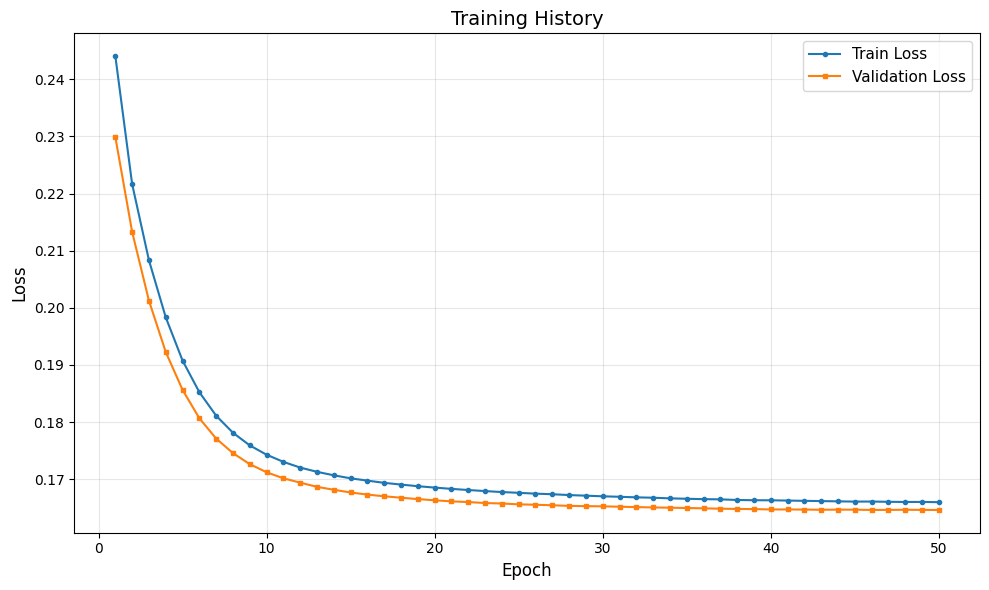

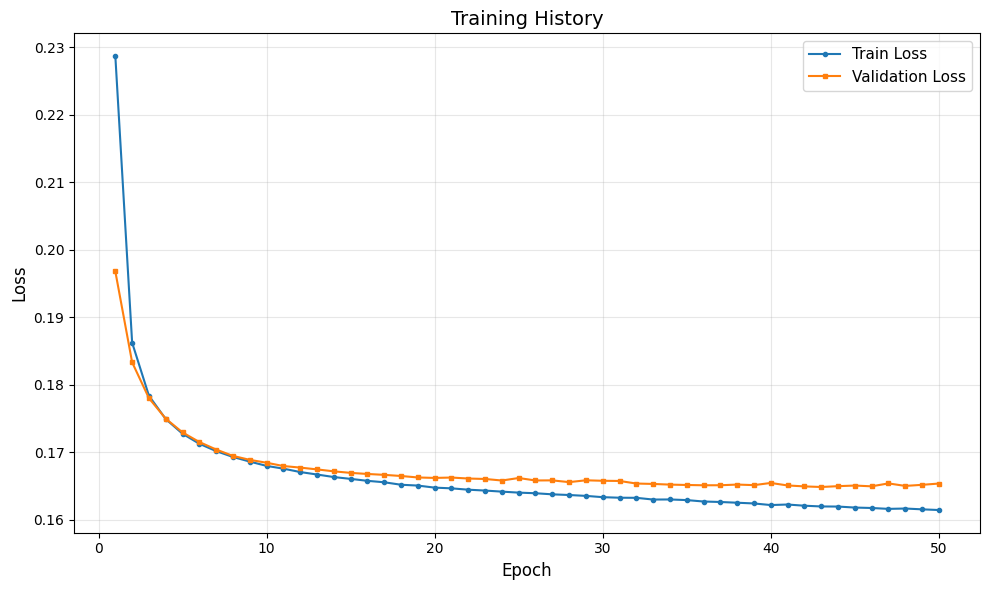

In [42]:
# Compare Training and Validation Loss Graphs
plotTrainingHistory(history_no_norm)
plotTrainingHistory(history_with_norm)

## Perbandingan Distribusi Bobot

In [43]:
# # Compare Weight Distributions
# # gw lupa buat atur nama file sama pathnya jadinya yang model_no_norm langsung ke overwrite utk sekarang. udh kemaleman
# plotWeightDistribution(model_no_norm.weights, [0,1,2])
# plotWeightDistribution(model_with_norm.weights, [0,1,2])

## Perbandingan Distribusi Gradien Bobot

In [44]:
# # Compare Gradient Distributions
# # Asumsikan grad sudah dihitung setelah backward terakhir
# plotGradientDistribution(model_no_norm.grad_w, [0, 1, 2])
# plotGradientDistribution(model_with_norm.grad_w, [0, 1, 2])